# 04_1 – Setup & Sampling

Alap notebook: importok, seed-ek, manifest betöltése és a 10 mintakép kiválasztása.

**Cél:** Ellenőrizni, hogy minden kép helyesen töltődik be és a seed-rendszer reprodukálható.

## 1. Imports, útvonalak, konstansok

A `v13`/`03c` importokat és konstansokat használjuk, változtatás nélkül.

In [ ]:
from __future__ import annotations

import math
import os
import warnings
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

try:
    from PIL import Image
    PIL_AVAILABLE = True
except ImportError:
    PIL_AVAILABLE = False

try:
    import cv2
    CV2_AVAILABLE = True
    print(f"cv2 elérhető: {cv2.__version__}")
except Exception:
    cv2 = None
    CV2_AVAILABLE = False
    print("⚠️  cv2 NEM elérhető – a legtöbb lépés kihagyódik.")

try:
    import mediapipe as mp
    from mediapipe.tasks import python as mp_python
    from mediapipe.tasks.python import vision as mp_vision
    MEDIAPIPE_AVAILABLE = True
    print("mediapipe elérhető")
except Exception:
    mp = mp_python = mp_vision = None
    MEDIAPIPE_AVAILABLE = False
    print("⚠️  mediapipe NEM elérhető – kézdetektálás kihagyható.")

# ── Projekt útvonalak ─────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_ROOT     = PROJECT_ROOT / "data"
NOTEBOOK_DIR  = PROJECT_ROOT / "notebooks"
MODEL_DIR     = PROJECT_ROOT / "models"
MANIFEST_PATH = DATA_ROOT / "split_manifest.csv"
OUTPUT_DIR    = PROJECT_ROOT / "output" / "03b_pipeline_debug"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Geometriai konstansok ──────────────────────────────────────────────────
CANONICAL_W   = 600          # kanonikus tér szélessége (px)
CANONICAL_H   = 80           # kanonikus tér magassága (px)
N_FRETS       = 24
FRET_RULE     = 17.817

# Bund n x-pozíciója ha a teljes nyak kitölti a kanonikus teret [0..N_FRETS]
# x_n = CANONICAL_W * (1 - 0.5^(n/12)) / 0.75
FRET_POS_FULL = np.array(
    [CANONICAL_W * (1.0 - 0.5 ** (n / 12.0)) / 0.75 for n in range(N_FRETS + 1)],
    dtype=np.float64,
)
# Normalizált pozíciók (0..1, ahol 1.0 = a 24. bund pozíciója)
FRET_POS_NORM = np.array(
    [1.0 - 0.5 ** (n / 12.0) for n in range(N_FRETS + 1)],
    dtype=np.float64,
)

FINGER_TIP_IDX = [4, 8, 12, 16, 20]   # MediaPipe ujjhegy landmark indexek
INLAY_FRETS    = [3, 5, 7, 9, 12]     # Standard 5 inlay pozíció
INLAY_FRETS_FULL = [3, 5, 7, 9, 12, 15, 17, 19, 21, 24]  # Mindkét oktáv

# Inlay normalizált x-pozíciók: az n. inlay a FRET_POS_NORM[n-1] és [n] közötti tér közepe
INLAY_NORM_DICT = {
    n: (FRET_POS_NORM[n - 1] + FRET_POS_NORM[n]) / 2.0
    for n in INLAY_FRETS_FULL
}

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Project root : {PROJECT_ROOT}")
print(f"Output dir   : {OUTPUT_DIR}")
print(f"FRET_POS_FULL[:7] = {np.round(FRET_POS_FULL[:7], 1)}")


cv2 elérhető: 4.13.0
mediapipe elérhető
Project root : /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition
Output dir   : /data/Tanulmányok/Képfeldolgozás alap algoritmusai/Féléves feladat/guitar-chord-recognition/output/03b_pipeline_debug
FRET_POS_FULL[:7] = [  0.   44.9  87.3 127.3 165.  200.7 234.3]


## 2. Seed-ek beállítása — HIBA 2 keret-rendszer

`FIXED_SEEDS = [42, 43]` rögzített, a másik **8 seed** futásonként random
(`np.random.default_rng()` belső állapotából). A teljes lista kiírásra kerül,
hogy ha valami furcsa eredmény jön, azt egy fix seedlistával reprodukálni lehessen.


In [ ]:
# HIBA 2: 10 kép – 2 fix + 8 random seed
FIXED_SEEDS = [42, 43]
_seed_rng   = np.random.default_rng()   # nincs seed → futásonként más
RANDOM_SEEDS = [int(_seed_rng.integers(0, 1_000_000)) for _ in range(8)]
ALL_SEEDS    = FIXED_SEEDS + RANDOM_SEEDS
print("ALL_SEEDS (notebook tetején):", ALL_SEEDS)


ALL_SEEDS (notebook tetején): [42, 43, 111587, 89260, 662891, 115826, 558025, 500246, 946240, 281700]


## 3. 10 kép mintavételezése a manifest-ből

A `data/split_manifest.csv` "train" split-jéből minden seed-hez 1 random képet
veszünk (`pandas.DataFrame.sample(n=1, random_state=seed)`). Így a fix seed-ek
ugyanazt a 2 képet adják minden futáskor, a 8 random pedig más-más képet.


In [ ]:
# Manifest betöltés + helper függvények (v13 cell 4 alapján, módosítva)
manifest = pd.read_csv(MANIFEST_PATH)
CLASSES  = sorted(manifest["class"].unique())
print(f"Összes kép: {len(manifest)}, osztályok: {CLASSES}")

def load_image_bgr(img_path: str):
    """BGR kép betöltése (cv2 elsődleges, PIL fallback)."""
    if CV2_AVAILABLE:
        img = cv2.imread(str(img_path))
        if img is not None:
            return img
    if PIL_AVAILABLE:
        arr = np.array(Image.open(img_path).convert("RGB"))
        return arr[:, :, ::-1].copy()
    return None

def bgr2rgb(img_bgr):
    if CV2_AVAILABLE:
        return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_bgr[:, :, ::-1]

# Seedenként 1 random train-kép
train_pool = manifest[manifest["split"] == "train"].reset_index(drop=True)
IMAGES = []
for s in ALL_SEEDS:
    row = train_pool.sample(n=1, random_state=s).iloc[0]
    IMAGES.append({
        "seed":  s,
        "path":  str(row["path"]),
        "class": row["class"],
        "fname": Path(row["path"]).name,
    })

for img in IMAGES:
    print(f"  seed={img['seed']:>6}  class={img['class']}  file={img['fname']}")


Összes kép: 297, osztályok: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'No hand']
  seed=    42  class=F  file=1762212514026.jpg
  seed=    43  class=B  file=IMG_20251102_024334.jpg
  seed=111587  class=B  file=IMG_20251102_024329.jpg
  seed= 89260  class=D  file=1762212432904.jpg
  seed=662891  class=B  file=IMG_20251102_024333.jpg
  seed=115826  class=C  file=IMG_20251102_024038.jpg
  seed=558025  class=B  file=IMG_20251102_024129.jpg
  seed=500246  class=D  file=IMG_20251102_023949_1.jpg
  seed=946240  class=B  file=IMG_20251102_024326.jpg
  seed=281700  class=C  file=IMG_20251102_024030.jpg


## 2. Képek megjelenítése

A 10 mintakép (2 fix seed + 8 random) 2×5 grid-ben. Alapvető ellenőrzés: töltődnek-e be, van-e kirívó fájlméret-probléma, jó-e a kép minősége?

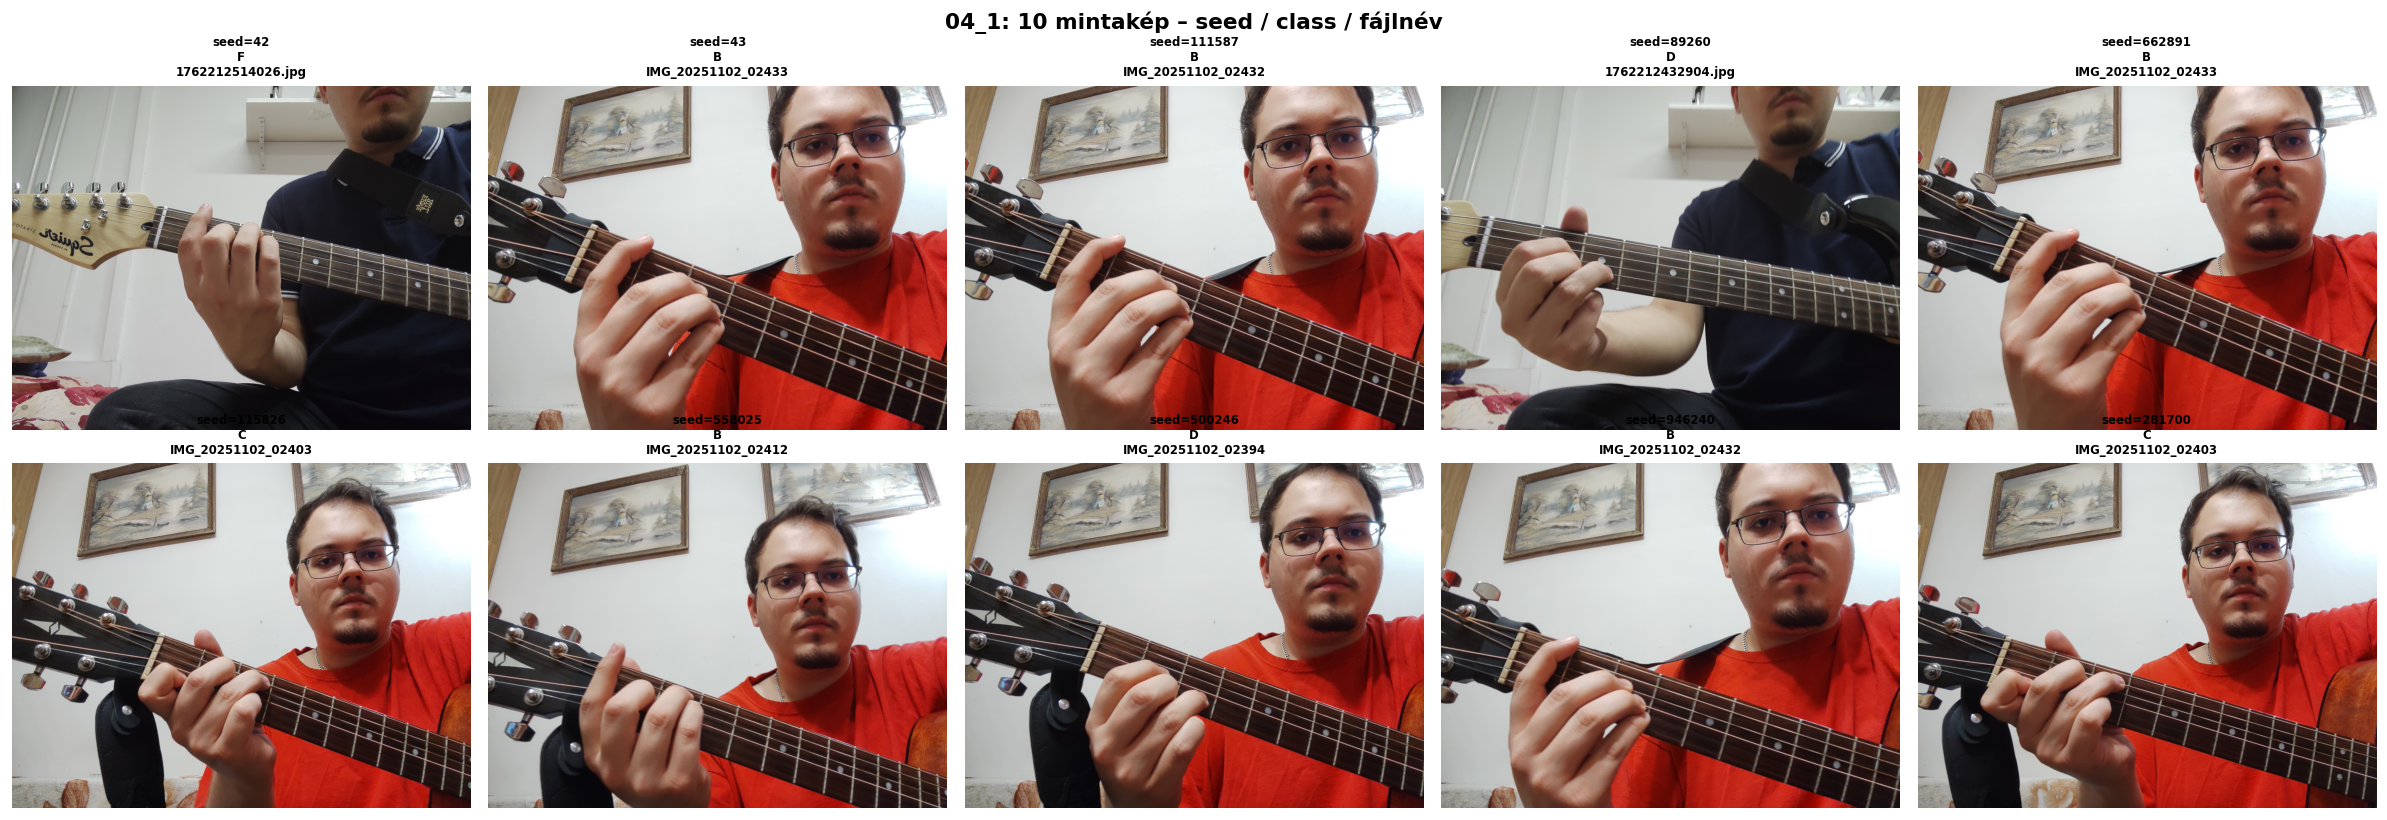

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle("04_1: 10 mintakép – seed / class / fájlnév", fontsize=13, fontweight="bold")
for ax, entry in zip(axes.ravel(), IMAGES):
    img = load_image_bgr(entry["path"])
    if img is None:
        ax.text(0.5, 0.5, "LOAD HIBA", ha="center", va="center",
                color="red", transform=ax.transAxes)
    else:
        ax.imshow(bgr2rgb(img))
        h, w = img.shape[:2]
        ax.set_xlabel(f"{w}×{h} px", fontsize=8)
    ax.set_title(f"seed={entry['seed']}\n{entry['class']}\n{entry['fname'][:18]}",
                 fontsize=7)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Összefoglaló

Ellenőrző lista:
- Minden kép betöltött? (LOAD HIBA = probléma)
- Minden kép valóban gitáros kép?
- Van-e ismétlődő kép (esetleg két seed ugyanazt a képet adta)?
- Megegyezik-e az `ALL_SEEDS` lista a notebook tetején és alján kiírt értékekkel?

In [ ]:
print('ALL_SEEDS (reprodukcióhoz):', ALL_SEEDS)

ALL_SEEDS (reprodukcióhoz): [42, 43, 111587, 89260, 662891, 115826, 558025, 500246, 946240, 281700]
